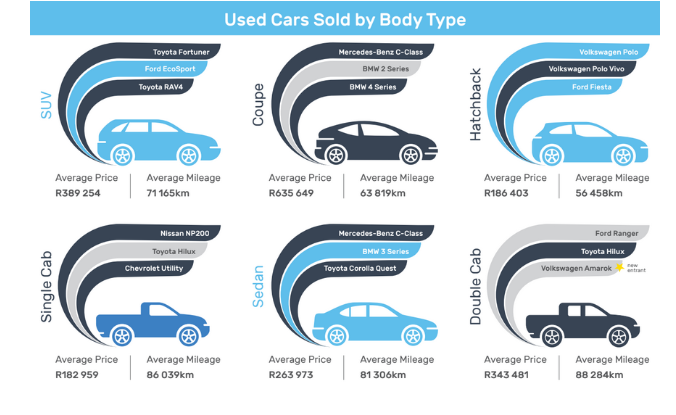

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: cyan; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About The Competition :</font></h3>
    
**Task**: To develop a model that can be used to predict the price of used cars based on various attributes.

**Dataset**: Training Dataset (train.csv): Contains features along with the target variable,price is the continuous target.Test Dataset (test.csv): Contains the features but requires predictions the value of price for each row.
    
**Evaluation**: The performance of the model is evaluated using the Root Mean Squared Error (RMSE), 

The dataset was generated from a deep learning model

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: lightgreen; font-size:100%; text-align:left">

<h3 align="center"><font color='green'>💡 Checklist When Buying a used car :</font></h3>


**When buying a used car, it's important to inspect every key areas to ensure one is making a sound investment. Here's a some checklist to consider:**

**Tyres:** Check for wear and tear, as replacing them can be expensive.
    
**Paintwork and Damage:** Look for scratches, dents, and other damage, which can affect the car's value and indicate how well it was maintained.
    
**Glass:** Inspect for cracks or chips in the windscreen and other windows, as these can impair driving and require costly repairs.

    
**Battery Health and Ignition:** Ensure the car starts easily and check the battery's condition. A weak battery or delayed start can indicate underlying issues.
    
**Corrosion:** Look for rust or corrosion, especially underneath the car and under the bonnet, as it can severely affect the car's mechanical integrity.
    
**Pedals:** Test the clutch, brakes, and accelerator to ensure they function properly and assess the wear level.
    
**Electrics & Bulbs:** Check all lights, dashboard indicators, electric windows, and other electrical components for proper functionality.
    
**Mileage:** Consider the car's mileage, as high mileage can indicate more wear and tear, affecting its value and reliability.
    
**Interior and Upholstery:** Examine the condition of the seats, dashboard, and flooring for signs of damage or excessive wear.
    
**Detailing:** Pay attention to small details like stitching, leather condition, and the state of the seatbelts and ceiling to gauge overall care.
    
**Testing a Used Car:**
Starting, Steering, and Braking: Ensure the car starts correctly, steers smoothly, and brakes effectively. Unusual sounds or behaviors during a test drive can indicate problems.
    
**Sound Health: Listen for any strange noises from the engine or other components, as they can signal mechanical issues.**
    
**Used Car History Checklist:**
1. **Documents: Verify all necessary paperwork, including the V5 for ownership transfer and service history records.** 
2. **Finance History: Ensure the car is fully paid off and not tied to any outstanding finance agreements.**
3. **Criminal History: Check for any criminal background, such as if the car was stolen or used in a crime.**
4. **MOT History: Review the MOT history to identify any recurring problems or missed tests, which could affect roadworthiness and value.**

**Conclusion: By thoroughly checking these aspects and doing a proper test drive and history check, you can make a more informed decision when purchasing a used car and avoid potential pitfalls**.

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Importing Libraries</h1>  
     
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import gc

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Evalaution Metric</h1>  
     
</div>

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">
    


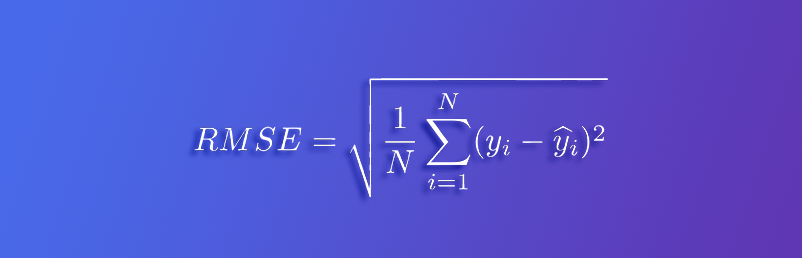


<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Loading  Dataset ♒🌊</h1>  
     
</div>

In [ ]:
df_sub=pd.read_csv("/kaggle/input/playground-series-s4e9/sample_submission.csv")
df_train=pd.read_csv("/kaggle/input/playground-series-s4e9/train.csv")
df_test=pd.read_csv("/kaggle/input/playground-series-s4e9/test.csv")

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: grey; padding: 10px; border-radius: 10px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Check </span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> on Data  📊</span> 
</p>

In [ ]:
df_train.head()

In [ ]:
df_test.head()

In [ ]:
df_test.shape,df_train.shape

In [ ]:
df_train = df_train.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>Data Talks :</font></h3>
    
**Intial Drop** : Drop Column ID....🎃
    
**Train & Test Distribution** : Looks Heavy no of rows 🎆    
    
**About Feature Columns** : We have 12 and 13 columns in which we can see, lots of features have missing value 🎭

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: grey; padding: 10px; border-radius: 10px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Checking  </span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Distribution of categorical features  📊</span> 
</p>

In [ ]:
df_train.info()

In [ ]:
df_test.info()

In [ ]:
df_train.isnull().sum()

In [ ]:
df_test.isnull().sum()

In [ ]:
df_train.columns

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='brand', y='price', data=df_train[:10000], errorbar=None)
plt.title('Average Price by Car Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='price', y='transmission', data=df_train[:1000],orient='h')
plt.title('Box Plot of Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.xticks(rotation=90) 
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='accident', y='price', data=df_train, errorbar=None)
plt.title('Average Price by Accident History')
plt.xlabel('Accident History')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='fuel_type', data=df_train)
plt.title('Count of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='transmission', data=df_train)
plt.title('Count of Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [ ]:
categorical_columns = df_train.select_dtypes(include=['object']).columns
unique_values = {col: df_train[col].nunique() for col in categorical_columns}
for col, unique_count in unique_values.items():
    print(f"{col}: {unique_count} unique values")
    
gc.collect()

In [ ]:
categorical_columns = df_test.select_dtypes(include=['object']).columns
unique_values = {col: df_test[col].nunique() for col in categorical_columns}
for col, unique_count in unique_values.items():
    print(f"{col}: {unique_count} unique values")
    
gc.collect()

In [ ]:
df_test.columns

In [ ]:
df_train.columns

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: black; padding: 20px; border-radius: 20px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Exploratory</span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Data Analysis(EDA)  📊</span> 
</p>

In [ ]:
import seaborn as sns

In [ ]:
missing_train = df_train.isna().mean() * 100
missing_test = df_test.isna().mean() * 100

print("Columns in df_train with more than 10% missing values:")
print(missing_train[missing_train > 0])

print("\nColumns in df_test with more than 10% missing values:")
print(missing_test[missing_test > 0])

In [ ]:
missing_values = df_train.isnull().mean() * 100
missing_values = missing_values[missing_values >0]
missing_values = missing_values.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values Distribution in df_train')
plt.show()

In [ ]:
!pip install dython

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import category_encoders as ce

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import category_encoders as ce

missing_threshold = 0.95

high_missing_columns = df_train.columns[df_train.isnull().mean() > missing_threshold]

df_train = df_train.drop(columns=high_missing_columns)
df_test = df_test.drop(columns=high_missing_columns)
target = 'class'

for column in df_train.columns:
    if df_train[column].isnull().any():      
        if df_train[column].dtype == 'object':
            mode_value = df_train[column].mode()[0]
            df_train[column].fillna(mode_value, inplace=True)
            df_test[column].fillna(mode_value, inplace=True)     
        else:
            median_value = df_train[column].median()
            df_train[column].fillna(median_value, inplace=True)
            df_test[column].fillna(median_value, inplace=True)

In [ ]:
from dython.nominal import associations

associations_df = associations(df_train, nominal_columns='all', plot=False)
corr_matrix = associations_df['corr']
plt.figure(figsize=(20, 8))
plt.gcf().set_facecolor('#FFFDD0') 
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix including Categorical Features')
plt.show()

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: lightgreen; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 What We got from data, Lets have a look :</font></h3>


🎍**Data Quality Issues Identified:**

🎟**Missing Values:**
🎇fuel_type: 2.69% missing (4,040 entries missing)
🎁accident: 1.28% missing (1,923 entries missing)
🎨clean_title: 11.32% missing (16,981 entries missing)

🥽**Modification Required:** Impute missing values using mode or a constant placeholder such as 'Unknown' for categorical columns.

🧵**High Cardinality:**
Columns like brand, transmission, ext_col, and int_col have many unique values (rare categories).

🎨**Modification Required:**
Consider grouping rare categories into a single "Other" category to reduce cardinality.
For ext_col and int_col, which have high cardinality, consider using hash encoding or text embedding techniques.

🎢**Outliers:**
milage: Contains 1,413 outliers with values exceeding the upper bound (202,259.50) or lower than the lower bound (-82,624.50).
price: Contains 8,637 outliers exceeding the upper bound (99,237.50) or lower than the lower bound (-32,342.50).

🥼**Modification Required:**
Cap or remove outliers to improve model robustness. one can cap at the upper bound or use IQR-based filtering.

🧨**Mixed Data Types:**
fuel_type and accident columns have mixed data types (e.g., objects and floats).
Suggestions: Convert these columns to a single consistent data type (e.g., string) before encoding.

🎃**Low Information Column:**
clean_title: Identified as a possible low-information column with high missingness (11.32%).

🧵**Modification Required:** Better dropping these column before modeling since it provides little to no additional information.

🎍**Possible Date-Time Column:**
model_year is recognized as a potential date-time column, which could represent the age of the vehicle.
Suggestions: Transform model_year into a feature representing the vehicle's age by calculating the difference from the current year.

In [ ]:
df_train.columns

cols_to_drop_train = missing_train[missing_train > 95].index
cols_to_drop_test = missing_test[missing_test > 95].index

df_train = df_train.drop(columns=cols_to_drop_train)
df_test = df_test.drop(columns=cols_to_drop_test)
gc.collect()

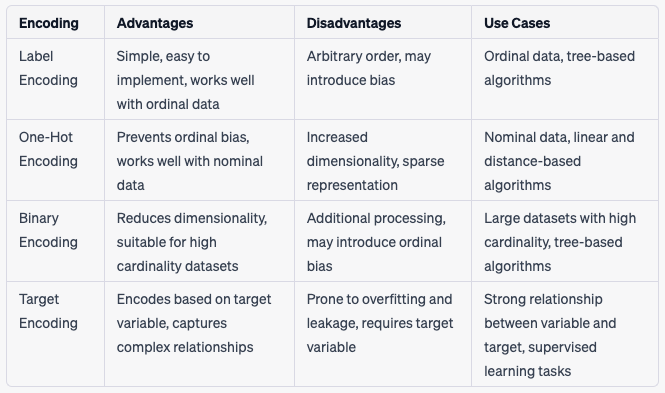

In [ ]:
from sklearn.impute import KNNImputer

def knn_impute(df, n_neighbors=5):   
    df_encoded = df.copy()
    for col in df_encoded.select_dtypes(include='object').columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imputed = pd.DataFrame(knn_imputer.fit_transform(df_encoded), columns=df_encoded.columns)
    for col in df.select_dtypes(include='object').columns:
        df_imputed[col] = df_imputed[col].round().astype(int).map(
            dict(enumerate(df[col].astype('category').cat.categories)))
    return df_imputed

In [ ]:
df_train_imputed = knn_impute(df_train, n_neighbors=25)
df_test_imputed = knn_impute(df_test, n_neighbors=25)

In [ ]:
cat_cols_train = df_train_imputed.select_dtypes(include=['object']).columns
cat_cols_train = cat_cols_train[cat_cols_train != 'class']
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

df_train_imputed[cat_cols_train] = ordinal_encoder.fit_transform(df_train_imputed[cat_cols_train].astype(str))
df_test_imputed[cat_cols_train] = ordinal_encoder.transform(df_test_imputed[cat_cols_train].astype(str))

In [ ]:
df_train_imputed.head()

In [ ]:
df_test_imputed.head()

In [ ]:
df_train = df_train_imputed
df_test = df_test_imputed

In [ ]:
#df_train.drop(columns=['brand','clean_title'], inplace=True)  
#df_test.drop(columns=['brand','clean_title'], inplace=True)  
#df_train = pd.get_dummies(df_train, columns=['engine'], drop_first=True)
#df_test = pd.get_dummies(df_test, columns=['engine'], drop_first=True)
#df_train['milage_per_year'] = df_train['milage'] / (2024 - df_train['model_year'])
#df_test['milage_per_year'] = df_test['milage'] / (2024 - df_test['model_year'])
#df_train['car_age'] = 2024 - df_train['model_year']
#df_test['car_age'] = 2024 - df_test['model_year']
df_train['engine_transmission'] = df_train['engine'] * df_train['transmission']
df_test['engine_transmission'] = df_test['engine'] * df_test['transmission']

In [ ]:
df_train.isnull().sum()

In [ ]:
current_year = 2024
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Tesla']


def create_features(df):
    #df['vehicle_age'] = current_year - df['model_year']  
    #df['vehicle_age_int'] = df['vehicle_age'].astype(int)
    #df['mileage_per_year'] = df['milage'] / df['vehicle_age']
    #df['mileage_per_year'].replace([np.inf, -np.inf], 0, inplace=True)   
    df['rare_fuel_type'] = df['fuel_type'].apply(lambda x: 0 if x in ['Petrol', 'Diesel'] else 1)
    df['is_automatic'] = df['transmission'].apply(lambda x: 1 if x == 'Automatic' else 0)
    df['has_accident_history'] = df['accident'].apply(lambda x: 1 if x != 'Unknown' and x != 'None' else 0)
    #df['engine_power_category'] = pd.qcut(df['engine'], q=3, labels=['Low', 'Medium', 'High'])
    df['color_match'] = df.apply(lambda row: 1 if row['ext_col'] == row['int_col'] else 0, axis=1)
    df['is_luxury_brand'] = df['brand'].apply(lambda x: 1 if x in luxury_brands else 0)
    return df
#df_train = create_features(df_train)
#df_test = create_features(df_test)

In [ ]:
df_train.head()

In [ ]:
df_test.shape,df_train.shape

In [ ]:
def remove_outliers_iqr(df, column):   
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1   
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR    
    df_out = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_out

df_train_no_outliers = remove_outliers_iqr(df_train, 'milage')
df_train_no_outliers = remove_outliers_iqr(df_train_no_outliers, 'price')
df_train_no_outliers.reset_index(drop=True, inplace=True)

In [ ]:
df_train

In [ ]:
df_train_no_outliers.head()

In [ ]:
df_train_no_outliers.isnull().sum()

In [ ]:
df_train_no_outliers.isnull().sum()

In [ ]:
df_train_no_outliers.head()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='price', data=df_train_no_outliers)
plt.title('Box Plot of Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model_year', y='price', data=df_train_no_outliers, errorbar=None)
plt.title('Average Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
x = df_train_no_outliers[:1000]
sns.pairplot(x[['price', 'milage', 'model_year', 'engine', 'fuel_type']], hue='fuel_type')
plt.suptitle('Pair Plot of Selected Features Colored by Fuel Type', y=1.02)
plt.show()

In [ ]:
#df_train = pd.get_dummies(df_train, columns=['engine_power_category'], prefix='engine_power')
#df_test = pd.get_dummies(df_test, columns=['engine_power_category'], prefix='engine_power')

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 Observation from above plot :</font></h3>
    


In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(x='transmission', y='price', data=df_train_no_outliers, errorbar=None)
plt.title('Average Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
y = df_train['price'] 
X = df_train.drop(['price'],axis=1)

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: cyan; padding: 20px; border-radius: 20px; border: 7px solid #2ca02c; width: 95%;">
  <span style="font-weight: bold; color: #ff7f0e; animation: pulse 2s infinite;"></span>Model Building |
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Training |</span> Regression

</p>

In [ ]:
#train_X, test_X, train_y, test_y = train_test_split(X, y,test_size = 0.2, random_state =42)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Classification Analysis♒🌊</h1>  
     
</div>

In [ ]:
df_train.shape

In [ ]:
df_train.columns

In [ ]:
df_test.shape

In [ ]:
df_test.columns

In [ ]:
df_train.head()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train_data = scaler.fit_transform(X)
scaled_test_data = scaler.transform(df_test)

In [ ]:
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

lgb_params={
                'num_leaves': 426,
                 'max_depth': 20,
                 'learning_rate': 0.011353178352988012,
                 'n_estimators': 10000,
                 'metric': 'rmse',
                 'subsample': 0.5772552201954328,
                 'colsample_bytree': 0.9164865430101521,
                 'reg_alpha': 1.48699088003429e-06,
                 'reg_lambda': 0.41539458543414265,
                 'min_data_in_leaf': 73,
                 'feature_fraction': 0.751673655170548,
                 'bagging_fraction': 0.5120415391590843,
                 'bagging_freq': 2,
                 'random_state': 42,
                 'min_child_weight': 0.017236362383443497,
                 'cat_smooth': 54.81317407769262,
                 'verbose' : -1,
                 'early_stopping_rounds': 200,
}


lgbm_predictions = np.zeros(len(scaled_train_data))
lgbm_true_labels = np.zeros(len(scaled_train_data))
lgbm_test_predictions = np.zeros(len(scaled_test_data))


for fold, (train_idx, val_idx) in enumerate(kf.split(scaled_train_data, y)):
    print(f"Training fold {fold + 1}/{n_splits}...")
    
    X_train, X_val = scaled_train_data[train_idx], scaled_train_data[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lgbm_model = LGBMRegressor(**lgb_params)

    lgbm_model.fit(X_train, y_train,
                   eval_set=[(X_val, y_val)],
                   eval_metric='rmse',
                   #early_stopping_rounds=10,
                   #verbose=False                
                  )

    
    lgbm_fold_preds = lgbm_model.predict(X_val)
    lgbm_fold_test_preds = lgbm_model.predict(scaled_test_data)

    lgbm_predictions[val_idx] = lgbm_fold_preds
    lgbm_true_labels[val_idx] = y_val
    lgbm_test_predictions += lgbm_fold_test_preds / n_splits 
    fold_rmse = np.sqrt(mean_squared_error(y_val, lgbm_fold_preds))
    print(f"Fold {fold + 1} RMSE: {fold_rmse:.4f}")

overall_rmse_lgbm = np.sqrt(mean_squared_error(lgbm_true_labels, lgbm_predictions))
print(f"Overall RMSE (LGBMRegressor): {overall_rmse_lgbm:.4f}")

In [ ]:
xgb_params={
     'lambda': 0.03880258557285165,
     'alpha': 0.02129832295514386,
     'colsample_bytree': 0.4,
     'subsample': 0.7,
     'learning_rate': 0.014,
     'max_depth': 17,
     'random_state': 2020,
     'min_child_weight': 85,
     'n_estimators': 10000,
     'early_stopping_rounds': 200,
#      'tree_method': 'gpu_hist'
    
}

n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

xgb_predictions = np.zeros(len(scaled_train_data))
xgb_true_labels = np.zeros(len(scaled_train_data))
xgb_test_predictions = np.zeros(len(scaled_test_data))

for fold, (train_idx, val_idx) in enumerate(kf.split(scaled_train_data, y)):
    print(f"Training fold {fold + 1}/{n_splits}...")
    
    X_train, X_val = scaled_train_data[train_idx], scaled_train_data[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model = XGBRegressor(**xgb_params)
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  eval_metric='rmse',
                  #early_stopping_rounds=10,
                  verbose=False)

    xgb_fold_preds = xgb_model.predict(X_val)
    xgb_fold_test_preds = xgb_model.predict(scaled_test_data)
    xgb_predictions[val_idx] = xgb_fold_preds
    xgb_true_labels[val_idx] = y_val
    xgb_test_predictions += xgb_fold_test_preds / n_splits  

    fold_rmse = np.sqrt(mean_squared_error(y_val, xgb_fold_preds))
    print(f"Fold {fold + 1} RMSE: {fold_rmse:.4f}")

overall_rmse_xgb = np.sqrt(mean_squared_error(xgb_true_labels, xgb_predictions))
print(f"Overall RMSE (XGBRegressor): {overall_rmse_xgb:.4f}")

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb_params={
    
'lambda': 0.168,
 'alpha': 1.43,
 'colsample_bytree': 0.6,
 'subsample': 1.0,
 'learning_rate': 0.005,
 'max_depth': 14,
 'random_state': 2024,
 'min_child_weight': 64,
 'n_estimators': 400,
    
 #'tree_method': 'gpu_hist'
 
}

model = XGBRegressor(
   **xgb_params
)
"""
model = XGBRegressor(
    alpha=0.1,
    learning_rate=0.1,
    #subsample=0.1,
    #colsample_bytree=0.1,
    objective='reg:squarederror', 
    max_depth=3,
    min_child_weight=4,
    gamma=1e-4,
    n_estimators=360
)"""
XGB = model.fit(
    train_X,
    train_y,
    eval_set=[(test_X, test_y)],
    eval_metric='rmse', 
)
y_pred = model.predict(test_X)
rmse_score = mean_squared_error(test_y, y_pred, squared=False) 
print("RMSE Score:", rmse_score)

In [ ]:
xgb_test_predictions

In [ ]:
lgbm_test_predictions

In [ ]:
df_sub['price']= lgbm_test_predictions*0.66+xgb_test_predictions*0.34

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🗞📜Final Submission♒🌊</h1>  
     
</div>

In [ ]:
df_sub.to_csv('submission.csv', index = False)
pd.read_csv('submission.csv')

In [ ]:
df_sub['price'].hist()

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡Refrences :</font></h3>

<div style="background-color: black; padding: 20px; border-radius: 10px; margin: 20px auto; max-width: 600px;">
    <center>
        <div style="background-color: white; padding: 20px; border-radius: 10px;">
            <b style="font-size: 24px; color: #ff6600;">👏😊 &nbsp; IF YOU FIND THIS HELPFUL, PLEASE UPVOTE! &nbsp; 💢👏</b>
            <div style="margin-top: 20px; font-size: 18px; color: black;">
                🥽🖥This took quite a bit of effort on my part, and while it might seem trivial, 🏆🏆receiving your appreciation means a lot to me! 😅🎃 Your upvotes inspire me to keep creating helpful content like this🖥🍱.                    
            </div>
        </div>
    </center>
</div>